In [1]:
# Importing setup file
from setup import *

# Link directory to save figures
out_path = "output/p34"
os.makedirs(out_path, exist_ok=True)

## Loading Dataset

In [2]:
translationDataset = load_file(translation=True, filePath=BASE_DIR/"data/vast_english_french.txt")

### Hyperparameters Independent to Dataset

In [ ]:
max_length = 100 # Max sentence length that shouldn't be exceeded in the dataset
batch_size = 1
epochs = 200

## Helper Functions

In [4]:
def forward_pass(model, input_tensor, target_tensor, criterion, output_size):
    # Flattening dimensions to allow passing into criterion
    output = model(input_tensor, target_tensor[:, :-1])
    loss = criterion(output.reshape(-1, output_size), target_tensor[:, 1:].reshape(-1))

    return loss

In [5]:
def train(model, input_tensor, target_tensor, optimizer, criterion, output_size):
    optimizer.zero_grad()
    loss = forward_pass(model, input_tensor, target_tensor, criterion, output_size)
    loss.backward()
    optimizer.step()

    return loss.item()

In [6]:
def train_model(model, train_loader, val_loader, output_size):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=0) # Ignoring the SOS token

    #Initializing loss variables
    train_losses = []
    val_losses = []

    start_time = time.time()

    for epoch in range(epochs):
        # Training Loop
        model.train()
        epoch_train_loss = 0.0

        for train_x, train_y in train_loader:
            X_train = train_x.to(device)
            Y_train = train_y.to(device)

            loss = train(model, input_tensor=X_train, target_tensor=Y_train, optimizer=optimizer, criterion=criterion, output_size=output_size)
            epoch_train_loss += loss
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Loop
        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for val_x, val_y in val_loader:
                X_val = val_x.to(device)
                Y_val = val_y.to(device)

                loss = forward_pass(model, input_tensor=X_val, target_tensor=Y_val, criterion=criterion, output_size=output_size)
                epoch_val_loss += loss.item()
            
        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}:\n Loss: {avg_train_loss:.3f}, Validation Loss: {avg_val_loss:.3f}')

    train_time = time.time() - start_time

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
        'train_time': train_time,
    }

In [7]:
def eval_show_eg(model, val_loader, idx_to_chars, output_size, n_eg=5):
    model.eval()

    exact_matches = 0.0
    total_bleu_score = 0.0
    chencherry = SmoothingFunction()

    print("\n")
    print("="*40)
    print("Generating Validation Examples")
    print("="*40)

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            input_tensor = input_tensor.to(device)
            target_tensor = target_tensor.to(device)

            # Decoding
            encoder_embedded = model.encoder_embedding(input_tensor)
            encoder_pos_embedded = model.encoder_pos_encoder(encoder_embedded)
            encoder_output = model.transformer_encoder(encoder_pos_embedded)

            # Starting with the SOS token
            decoder_input = torch.tensor([[SOS_token]], device=device)
            predicted_id = []

            for _ in range(max_length):
                decoder_embedded = model.decoder_embedding(decoder_input)
                decoder_pos_embedded = model.decoder_pos_encoder(decoder_embedded)
                decoder_output = model.transformer_decoder(decoder_pos_embedded, encoder_output)
                output = model.fc(decoder_output[:, -1, :])

                _, topi = output.topk(1)
                idx = topi.item()
                predicted_id.append(idx)
                
                decoder_input = torch.cat([decoder_input, torch.tensor([[idx]], device=device)], dim=1)

                if idx == EOS_token:
                    break
            
            # Converting to strings
            inp_string = ''.join([idx_to_chars[id.item()] for id in input_tensor[0] if id.item() not in (SOS_token, EOS_token)])
            tgt_string = ''.join([idx_to_chars[id.item()] for id in target_tensor[0] if id.item() not in (SOS_token, EOS_token)])
            predicted_string = ''.join([idx_to_chars[id] for id in predicted_id if id not in (SOS_token, EOS_token)])
            
            # Traditional Sequence Accuracy
            if predicted_string == tgt_string:
                exact_matches += 1

            # BLEU Score
            ref_tokens = [list(tgt_string)]
            candidate_tokens = list(predicted_string)
            
            bleu = sentence_bleu(ref_tokens, candidate_tokens, smoothing_function=chencherry.method1)
            total_bleu_score += bleu

            # Generating text samples
            if i < n_eg:
                match_status = "PASS" if predicted_string == tgt_string else "FAIL"
                print(f'Input: {inp_string:<12} |   Target: {tgt_string:<12}    |   Predicted: {predicted_string:<12}   |   Match: {match_status:<4}')
        
        final_acc = exact_matches / len(val_loader)
        avg_bleu = total_bleu_score / len(val_loader)

    return final_acc, avg_bleu
            

In [8]:
def print_results(results):
    for metric_name, key, fmt in [
    ("Final Train Loss",    "final_train_loss", ".4f"),
    ("Final Val Loss",      "final_val_loss",   ".4f"),
    ("Traditional Sequence Accuracy", "seq_acc", ".4f"),
    ("Validation BLEU-4 Score",   "avg_bleu",   ".4f"),
    ("Train Time (s)",      "train_time",       ".2f"),
    ]:
        print("\n")
        print(f'{metric_name}')
        print("="*15)
        for config in transformer_configs:
            nlayers = config['num_layers']
            nheads = config['nhead']

            value = results[nlayers][nheads][key]
            
            try:
                print(f'Layers: {nlayers}, Heads: {nheads} --> Value: {value:{fmt}}')
            except (ValueError, TypeError):
                print(f'Layers: {nlayers}, Heads: {nheads} --> Value: {value}')

## Main Functions

In [ ]:
def eng2Fra():
    part3 = {}

    # Building vocab
    unique_chars, chars_to_idx, idx_to_chars, encoded_text = vocab(translation=True, dataset=translationDataset)

    # Dependent Hyperparameters
    input_size = len(chars_to_idx)
    output_size = input_size

    for config in transformer_configs:
        nlayers = config["num_layers"]
        nheads = config["nhead"]

        #Instantiating required model variables
        model = translationTransformer(input_size=input_size, hidden_size=hidden_size, output_size=output_size, num_layers=nlayers, nhead=nheads).to(device)
        dataset = TranslationDataset(dataset=translationDataset, chars_to_idx=chars_to_idx)
        train_loader, val_loader = build_loaders(dataset=dataset, batch_size=batch_size)

        # Initializing results dictionary
        if nlayers not in part3:
            part3[nlayers] = {}
        part3[nlayers][nheads] = {}

        print("\n")
        print("="*50)
        print(f'Number of Layers: {nlayers}   |   Number of heads: {nheads}')
        print("="*50)

        metrics = train_model(model, train_loader=train_loader, val_loader=val_loader, output_size=output_size)
        seq_acc, avg_bleu = eval_show_eg(model=model, val_loader=val_loader, idx_to_chars=idx_to_chars, output_size=output_size)

        part3[nlayers][nheads] = {
            **metrics,
            "seq_acc":  seq_acc,
            "avg_bleu": avg_bleu,
        }

        plot_loss(train_losses=part3[nlayers][nheads]["train_losses"], val_losses=part3[nlayers][nheads]["val_losses"],
                  title=f'English-to-French Translation Trained with Transformer Model (Layers: {nlayers}, Heads: {nheads})',
                  path=f'{out_path}/translationTransformer_eng2fra_layers{nlayers}_head{nheads}_evalCurve')
    
    print("English-to-French Translation Results:")
    print_results(part3)

In [ ]:
def fra2Eng():
    part4 = {}

    # Reversing the dataset for French-to-English 
    translationDataset_reversed = [(fra, eng) for eng, fra in translationDataset]

    # Rebuilding vocab
    unique_chars, chars_to_idx, idx_to_chars, encoded_text = vocab(translation=True, dataset=translationDataset_reversed)

    # Dependent Hyperparameters
    input_size = len(chars_to_idx)
    output_size = input_size

    for config in transformer_configs:
        nlayers = config["num_layers"]
        nheads = config["nhead"]

        #Instantiating required model variables
        model = translationTransformer(input_size=input_size, hidden_size=hidden_size, output_size=output_size, num_layers=nlayers, nhead=nheads).to(device)
        dataset = TranslationDataset(dataset=translationDataset_reversed, chars_to_idx=chars_to_idx)
        train_loader, val_loader = build_loaders(dataset=dataset, batch_size=batch_size)

        # Initializing results dictionary
        if nlayers not in part4:
            part4[nlayers] = {}
        part4[nlayers][nheads] = {}

        print("\n")
        print("="*50)
        print(f'Number of Layers: {nlayers}   |   Number of heads: {nheads}')
        print("="*50)

        metrics = train_model(model, train_loader=train_loader, val_loader=val_loader, output_size=output_size)
        seq_acc, avg_bleu = eval_show_eg(model=model, val_loader=val_loader, idx_to_chars=idx_to_chars, output_size=output_size)

        part4[nlayers][nheads] = {
            **metrics,
            "seq_acc":  seq_acc,
            "avg_bleu": avg_bleu,
        }

        plot_loss(train_losses=part4[nlayers][nheads]["train_losses"], val_losses=part4[nlayers][nheads]["val_losses"],
                  title=f'French-to-English Translation Trained with Transformer Model (Layers: {nlayers}, Heads: {nheads})',
                  path=f'{out_path}/translationTransformer_fra2eng_layers{nlayers}_head{nheads}_evalCurve')

    print("French-to-English Translation Results:")    
    print_results(part4)

PROBLEM 3: English-to-French Translation | 6 Transformer Configurations


Number of Layers: 1   |   Number of heads: 2
Epoch 10:
 Loss: 2.091, Validation Loss: 2.122
Epoch 20:
 Loss: 1.842, Validation Loss: 2.129
Epoch 30:
 Loss: 1.591, Validation Loss: 2.216
Epoch 40:
 Loss: 1.341, Validation Loss: 2.444
Epoch 50:
 Loss: 1.213, Validation Loss: 2.633
Epoch 60:
 Loss: 1.041, Validation Loss: 2.790
Epoch 70:
 Loss: 0.936, Validation Loss: 2.903
Epoch 80:
 Loss: 0.884, Validation Loss: 3.072
Epoch 90:
 Loss: 0.803, Validation Loss: 3.122
Epoch 100:
 Loss: 0.780, Validation Loss: 3.149


Generating Validation Examples
Input: He replies to all customer emails immediately |   Target: Il répond immédiatement à tous les e-mails des clients    |   Predicted: s pareçu une invitation à la fête   |   Match: FAIL
Input: We work in the office |   Target: Nous travaillons au bureau    |   Predicted:  l voyate undé   |   Match: FAIL
Input: I want a large slice of chocolate cake |   Target: Je veux un

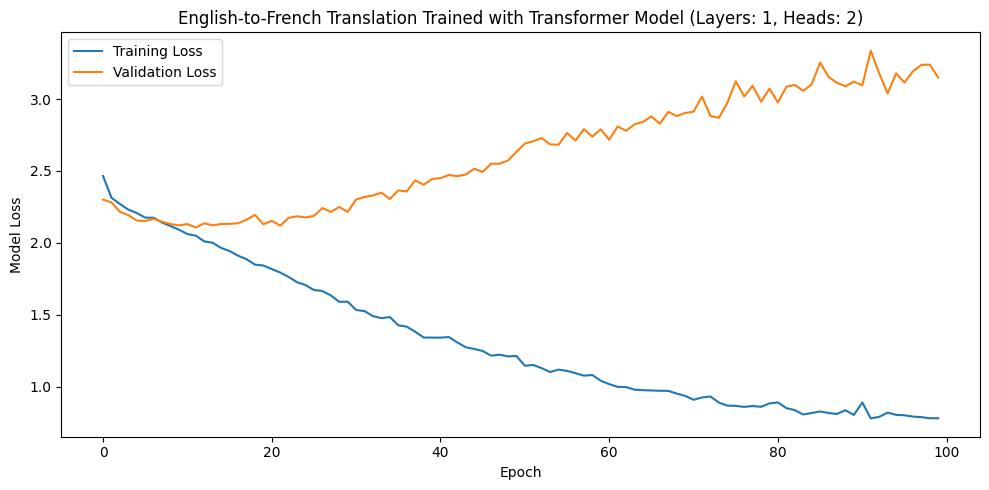



Number of Layers: 1   |   Number of heads: 4
Epoch 10:
 Loss: 2.036, Validation Loss: 2.075
Epoch 20:
 Loss: 1.739, Validation Loss: 2.057
Epoch 30:
 Loss: 1.438, Validation Loss: 2.273


KeyboardInterrupt: 

In [11]:
print("=" * 70)
print("PROBLEM 3: English-to-French Translation | 6 Transformer Configurations")
print("=" * 70)

eng2Fra()

print("=" * 70)
print("PROBLEM 4: French-to-English Translation | 6 Transformer Configurations")
print("=" * 70)

fra2Eng()